<a href="https://colab.research.google.com/github/sammigachuhi/masters_ai_colab/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **Logistic Regression**
* Define Logistic Regression
* What does Logistic Regression do?
* How does Logistic Regression work?
  - Sigmoid function
  - Softmax Function
* Application of logistic regression for multiclass problems
* App that shows logistic regression in action

# Sigmoid Function

## Explanation of Sigmoid Function
[Ref](https://medium.com/@bharataameriya/sigmoid-function-in-machine-learning-a09fd3213d74)

For large positive x, sigmoid outputs values close to 1
For large negative x, sigmoid outputs values close to 0
For x = 0, the function returns 0.5

In [ ]:
# Install required packages
!pip install plotly

In [ ]:
!pip install yellowbrick

In [ ]:
# Importt requisite packages
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
np.exp?

In [ ]:
# Generate values
x = np.linspace(-10, 10, 100)
y = sigmoid(x)

In [ ]:
np.linspace?

In [ ]:
x

array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
        -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
        -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
        -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
        -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
        -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
        -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
        -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
        -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
        -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
        -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
        -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
        -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
         0.50505051,   0.70707071,   0.90909091,   1.11111111,
         1.31313131,   1.51515152,   1.71717172,   1.91919192,
         2.12121212,   2.32323232,   2.52525253,   2.72

In [ ]:
# Plot the function
fig = px.line(x=x, y=y, title="Sigmoid curve")
fig.show()

In [ ]:
px.line?

## Derivative of Sigmoid Function

In [ ]:
def sigmoid_derivative(x):
  return sigmoid(x) * (1 - sigmoid(x))

# Compute derivative values
y_derivative = sigmoid_derivative(x)


In [ ]:
# Plot the function
fig = px.line(x=x, y=y_derivative, markers=True, title="Sigmoid derivative")
fig.show()

# Softmax
[Ref](https://www.geeksforgeeks.org/artificial-intelligence/multiclass-logistic-regression/)


[Ref](https://medium.com/@amit25173/understanding-softmax-with-numpy-b7273d8ab205)

In [ ]:
def softmax(x):
  exp_x = np.exp(x - np.max(x))
  return exp_x / np.sum(exp_x)

scores = [2.0, 1.0, 0.1]
probabilities = softmax(scores)
print(f"Softmax probabilities: {probabilities}")


Softmax probabilities: [0.65900114 0.24243297 0.09856589]


In [ ]:
probabilities

array([0.65900114, 0.24243297, 0.09856589])

In [ ]:
# Plot the function
fig = px.line(x=scores, y=np.array(probabilities), markers=True, title="Softmax Function")
fig.show()

In [ ]:
# Without numerical stability
unstable_exp = np.exp([1000, 1001, 1002])
print("Unstable Exponentials:", unstable_exp)  # This will likely cause an overflow error


Unstable Exponentials: [inf inf inf]


/tmp/ipykernel_301/2174884174.py:2: RuntimeWarning:

overflow encountered in exp



In [ ]:
# With stability
stable_exp = np.exp([(1000-1002), (1001 - 1002), (1002-1002)])
print("Stable Exponentials:", stable_exp)

Stable Exponentials: [0.13533528 0.36787944 1.        ]


In [ ]:
# Return softmax
softmax = stable_exp / np.sum(stable_exp)
print(f"Softmax: {softmax}")

Softmax: [0.09003057 0.24472847 0.66524096]


We subtract from the maximum for numerical stability. If it remains as it is and we work with large numbers, it may lead to an overflow error because remember, exponentials is multiplying the number by itself.

We divide by the sum so that we normalize the numbers so that they can all add up to 1.

# Logistic regression practical

[Ref](https://medium.com/@jshaik2452/multi-class-logistic-regression-a-friendly-guide-to-classifying-the-many-4a590c2e6c26)

First load in the wine dataset.

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/csa806-big-data/data/wine_data.csv")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


In [ ]:
value = "grade_"
def add_val(x):
  return f"{value}{x}"

df["quality"] = df["quality"].apply(add_val)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,grade_3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,grade_3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,grade_3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,grade_3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,grade_3


In [ ]:
# Get some statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         21000 non-null  float64
 1   volatile_acidity      21000 non-null  float64
 2   citric_acid           21000 non-null  float64
 3   residual_sugar        21000 non-null  float64
 4   chlorides             21000 non-null  float64
 5   free_sulfur_dioxide   21000 non-null  float64
 6   total_sulfur_dioxide  21000 non-null  float64
 7   density               21000 non-null  float64
 8   pH                    21000 non-null  float64
 9   sulphates             21000 non-null  float64
 10  alcohol               21000 non-null  float64
 11  quality               21000 non-null  object 
dtypes: float64(11), object(1)
memory usage: 1.9+ MB


In [ ]:
df.describe() # Descriptive statistics

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,9.797079,0.774796,0.793870,31.289348,0.200245,129.442333,229.008762,1.009972,3.158712,1.020641,11.291716
std,2.413919,0.365015,0.384833,19.015391,0.124933,77.167262,100.183265,0.012032,0.171371,0.408304,1.182198
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,7.600000,0.430000,0.410000,9.800000,0.072000,45.000000,150.000000,0.997417,3.030000,0.620000,10.400000
50%,10.000000,0.830000,0.870000,37.600000,0.205000,145.800000,240.500000,1.012200,3.150000,1.080000,11.300000
75%,11.800000,1.080000,1.110000,46.800000,0.298000,194.325000,311.625000,1.019840,3.270000,1.360000,12.200000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
# from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Features and target
X = df.drop(columns="quality")
y = df["quality"]

In [ ]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0
...,...,...,...,...,...,...,...,...,...,...,...
20995,9.7,1.020,0.91,50.00,0.412,114.6,181.7,1.02085,3.30,0.89,12.0
20996,10.2,0.610,0.88,53.80,0.250,62.4,204.7,1.02776,3.52,1.14,9.7
20997,13.4,0.460,1.04,52.10,0.449,63.0,273.5,1.02618,2.89,1.76,9.3
20998,6.6,1.030,1.09,25.30,0.138,179.8,295.0,1.02476,2.94,1.54,12.9


In [ ]:
y

,quality
0,grade_3
1,grade_3
2,grade_3
3,grade_3
4,grade_3
...,...
20995,grade_9
20996,grade_9
20997,grade_9
20998,grade_9


In [ ]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# Initialize and train the multi-class logistic regression model
model = LogisticRegression(
    multi_class= "multinomial",
    solver= "newton-cg", # "lbfgs", # Limited-memory Broyden-Fletcher-Goldfarb-Shanno generally good
    max_iter=200 #Maximum number of iterations taken for the solvers to converge.
)

In [ ]:
LogisticRegression?

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(max_iter=200, multi_class='multinomial', solver='newton-cg')

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.29


In [ ]:
report0 = classification_report(y_test, y_pred)
print(f"Classification report:\n {report0}")

Classification report:
               precision    recall  f1-score   support

     grade_3       0.22      0.28      0.24       887
     grade_4       0.18      0.13      0.15       896
     grade_5       0.54      0.40      0.46       954
     grade_6       0.49      0.71      0.58       888
     grade_7       0.17      0.11      0.13       898
     grade_8       0.20      0.12      0.15       919
     grade_9       0.19      0.31      0.24       858

    accuracy                           0.29      6300
   macro avg       0.28      0.29      0.28      6300
weighted avg       0.29      0.29      0.28      6300



In [ ]:
class_names = df["quality"].unique()
class_names

array(['grade_3', 'grade_4', 'grade_5', 'grade_6', 'grade_7', 'grade_8',
       'grade_9'], dtype=object)

Confusion matrix, without normalization
[[252 135  16   2 118  89 275]
 [216 118  45  27 117  98 275]
 [ 84  52 380 293  28  30  87]
 [ 14   6 204 630  13  11  10]
 [141  87  28 274  99  90 179]
 [234 134  18  57  91 108 277]
 [230 137   8   4 106 108 265]]
Normalized confusion matrix
[[0.28410372 0.15219842 0.01803833 0.00225479 0.13303269 0.10033822
  0.31003382]
 [0.24107143 0.13169643 0.05022321 0.03013393 0.13058036 0.109375
  0.30691964]
 [0.08805031 0.05450734 0.39832285 0.30712788 0.0293501  0.03144654
  0.09119497]
 [0.01576577 0.00675676 0.22972973 0.70945946 0.01463964 0.01238739
  0.01126126]
 [0.15701559 0.09688196 0.0311804  0.30512249 0.11024499 0.10022272
  0.19933185]
 [0.25462459 0.14581066 0.01958651 0.06202394 0.09902067 0.11751904
  0.30141458]
 [0.26806527 0.15967366 0.00932401 0.004662   0.12354312 0.12587413
  0.30885781]]


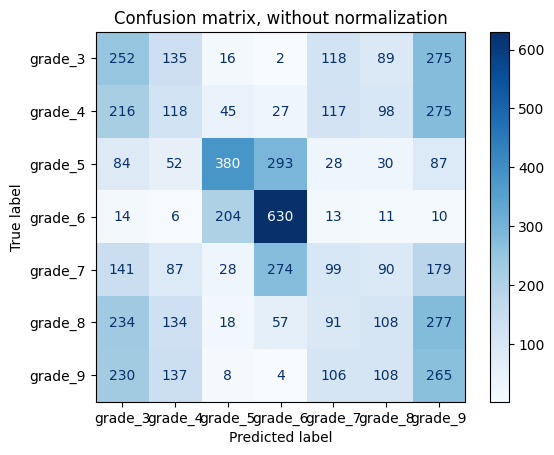

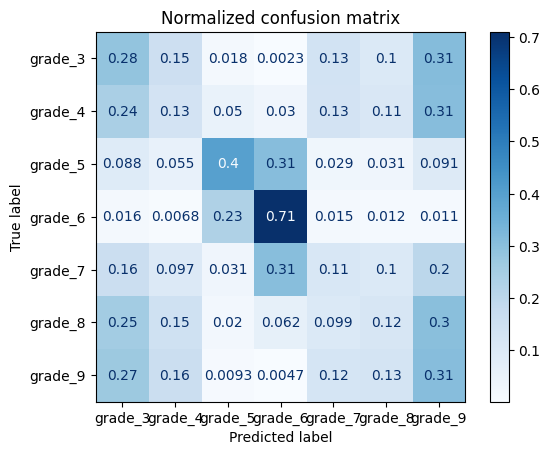

In [ ]:
# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# After normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
features = X.columns
features

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [ ]:
scaler = StandardScaler()
X_standardized = X.copy()
X_standardized[features] = scaler.fit_transform(X[features])
X_standardized.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.746903,-0.533679,-0.347872,-1.529816,-1.010526,-1.547874,-1.816801,-0.762353,0.532705,-1.103717,-1.938567
1,0.249775,-0.451489,-0.789632,-1.535075,-0.001962,-1.612670,-2.126242,-0.878712,0.007517,-0.956764,-2.446108
2,-0.993047,1.123827,-2.062940,-1.422006,-0.826423,-1.612670,-2.146206,-1.111431,2.750170,-1.177194,-0.500533
3,0.249775,-0.917234,-0.971533,-1.566629,-0.442208,-1.236854,-1.806819,-0.968475,1.291312,-0.393445,-1.177255
4,-0.620201,0.671780,-2.010969,-1.466707,-0.930481,-1.599710,-2.176151,-0.918607,1.874855,-1.299654,-0.246763


In [ ]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.3, random_state=42
)

In [ ]:
# Initialize and train the multi-class logistic regression model
model = LogisticRegression(
    multi_class= "multinomial",
    solver= "lbfgs", # Limited-memory Broyden-Fletcher-Goldfarb-Shanno generally good
    max_iter=400 #Maximum number of iterations taken for the solvers to converge.
)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(max_iter=400, multi_class='multinomial')

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.29


In [ ]:
y_test

,quality
2312,grade_3
16845,grade_8
6105,grade_5
18082,grade_9
11335,grade_6
...,...
2562,grade_3
19682,grade_9
19988,grade_9
3198,grade_4


In [ ]:
# Classification report
report = classification_report(y_test, y_pred)
print(f"Classification report:\n {report}")

Classification report:
               precision    recall  f1-score   support

     grade_3       0.21      0.28      0.24       887
     grade_4       0.16      0.12      0.14       896
     grade_5       0.54      0.41      0.46       954
     grade_6       0.49      0.70      0.58       888
     grade_7       0.16      0.09      0.12       898
     grade_8       0.22      0.15      0.18       919
     grade_9       0.19      0.29      0.23       858

    accuracy                           0.29      6300
   macro avg       0.28      0.29      0.28      6300
weighted avg       0.28      0.29      0.28      6300



In [ ]:
class_names = df["quality"].unique()
class_names

array(['grade_3', 'grade_4', 'grade_5', 'grade_6', 'grade_7', 'grade_8',
       'grade_9'], dtype=object)

Confusion matrix, without normalization
[[248 144  15   2  99 123 256]
 [228 107  47  27 114 117 256]
 [ 80  49 387 287  31  32  88]
 [ 13   6 215 621  10  12  11]
 [144  97  31 273  84  88 181]
 [221 138  16  57  89 140 258]
 [227 142   9   4  99 126 251]]
Normalized confusion matrix
[[0.27959414 0.16234498 0.01691094 0.00225479 0.11161218 0.13866967
  0.2886133 ]
 [0.25446429 0.11941964 0.05245536 0.03013393 0.12723214 0.13058036
  0.28571429]
 [0.08385744 0.05136268 0.40566038 0.30083857 0.03249476 0.03354298
  0.09224319]
 [0.01463964 0.00675676 0.24211712 0.69932432 0.01126126 0.01351351
  0.01238739]
 [0.16035635 0.10801782 0.03452116 0.30400891 0.0935412  0.09799555
  0.20155902]
 [0.24047878 0.15016322 0.01741023 0.06202394 0.0968444  0.1523395
  0.28073993]
 [0.26456876 0.16550117 0.01048951 0.004662   0.11538462 0.14685315
  0.29254079]]


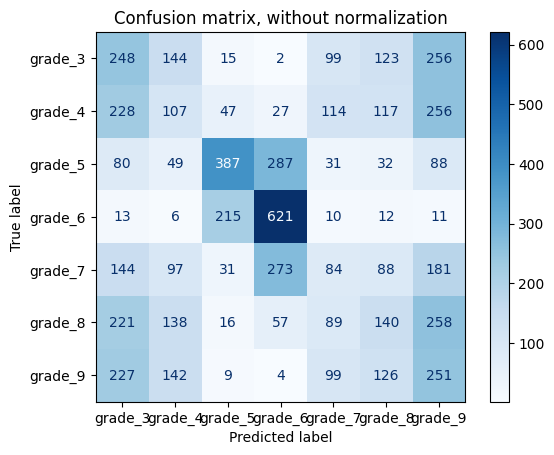

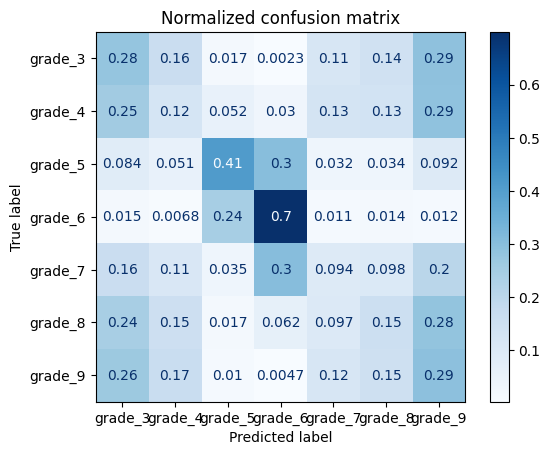

In [ ]:
# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
parameter_grid_logistic_regression = {
    'max_iter': [20, 50, 100, 200, 500, 1000],                      # Number of iterations
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],   # Algorithm to use for optimization
    'multi_class': ["multinomial"]                                   # Troubleshoot unbalanced data sampling
}

In [ ]:
logistic_model_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=parameter_grid_logistic_regression, verbose=3,
                    cv=10, n_jobs=-1)

In [ ]:
GridSearchCV?

In [ ]:
logistic_model_grid.fit(X_train, y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


60 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1267, in fit
    multi_class = _check

GridSearchCV(cv=10, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': [20, 50, 100, 200, 500, 1000],
                         'multi_class': ['multinomial'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             verbose=3)

In [ ]:

print("Best score for the model after tuning is: ",logistic_model_grid.best_score_)
print("Best parameters for the model is :",logistic_model_grid.best_estimator_)

Best score for the model after tuning is:  0.3019047619047619
Best parameters for the model is : LogisticRegression(max_iter=20, multi_class='multinomial', random_state=42,
                   solver='sag')


In [ ]:
# Make predictions
y_pred = logistic_model_grid.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.29


In [ ]:
# Classification report
report = classification_report(y_test, y_pred)
print(f"Classification report:\n {report}")

Classification report:
               precision    recall  f1-score   support

     grade_3       0.21      0.28      0.24       887
     grade_4       0.16      0.12      0.14       896
     grade_5       0.53      0.41      0.46       954
     grade_6       0.49      0.69      0.57       888
     grade_7       0.16      0.09      0.12       898
     grade_8       0.21      0.15      0.17       919
     grade_9       0.19      0.29      0.23       858

    accuracy                           0.29      6300
   macro avg       0.28      0.29      0.28      6300
weighted avg       0.28      0.29      0.28      6300



Confusion matrix, without normalization
[[248 144  15   2  99 123 256]
 [228 107  47  27 114 117 256]
 [ 80  49 387 287  31  32  88]
 [ 13   6 215 621  10  12  11]
 [144  97  31 273  84  88 181]
 [221 138  16  57  89 140 258]
 [227 142   9   4  99 126 251]]
Normalized confusion matrix
[[0.27959414 0.16234498 0.01691094 0.00225479 0.11161218 0.13866967
  0.2886133 ]
 [0.25446429 0.11941964 0.05245536 0.03013393 0.12723214 0.13058036
  0.28571429]
 [0.08385744 0.05136268 0.40566038 0.30083857 0.03249476 0.03354298
  0.09224319]
 [0.01463964 0.00675676 0.24211712 0.69932432 0.01126126 0.01351351
  0.01238739]
 [0.16035635 0.10801782 0.03452116 0.30400891 0.0935412  0.09799555
  0.20155902]
 [0.24047878 0.15016322 0.01741023 0.06202394 0.0968444  0.1523395
  0.28073993]
 [0.26456876 0.16550117 0.01048951 0.004662   0.11538462 0.14685315
  0.29254079]]


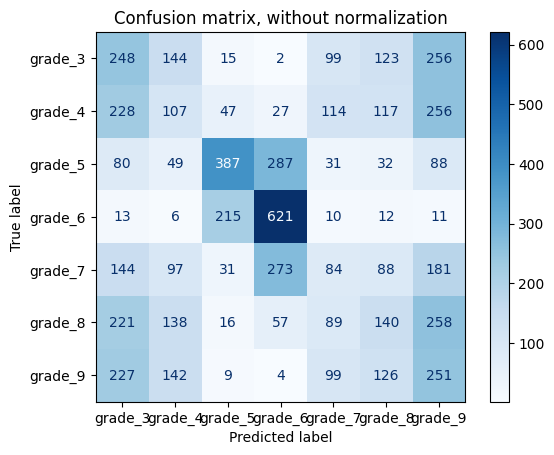

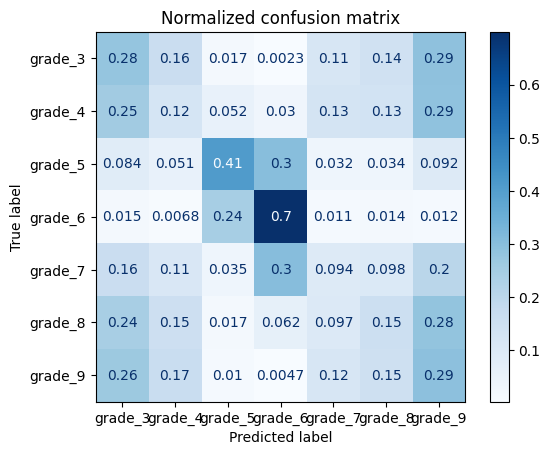

In [ ]:
# Get class names
class_names = df["quality"].unique()
class_names

# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# Dash app
Create a dash app that does the following

* The function will use the gridsearch to search for the best hyperparameters.

* It will print accuracy

* It will print classification report

* It will display confusion matrix display

In [ ]:
# Set parameters
parameters = {
    'max_iter': [20, 50, 100, 200, 500, 1000],                      # Number of iterations
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],   # Algorithm to use for optimization
    'multi_class': ["multinomial"]
}

In [ ]:
def logistic_regression_func(path_to_df, target_column, grid_search_params, affix=""):
  """

  """
  # Import requisite packages
  import plotly.express as px
  import numpy as np
  import matplotlib.pyplot as plt
  from sklearn.preprocessing import MinMaxScaler, StandardScaler
  from sklearn.model_selection import train_test_split
  from sklearn.linear_model import LogisticRegression
  from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
  # from sklearn.metrics import ConfusionMatrixDisplay

  df = pd.read_csv(path_to_df)

  # Only to be applied if the column is a numerical value
  value = f"{affix}_"
  def add_val(x):
    return f"{value}{x}"

  df[target_column] = df[target_column].apply(add_val)

  # Features and target
  X = df.drop(columns=target_column)
  y = df[target_column]

  # Features
  features = X.columns

  # Standardize
  scaler = StandardScaler()
  X_standardized = X.copy()
  X_standardized[features] = scaler.fit_transform(X[features])
  X_standardized.head()

  # Split the dataset into training and test sets
  X_train, X_test, y_train, y_test = train_test_split(
      X_standardized, y, test_size=0.3, random_state=42
  )

  # GridSearchCV
  logistic_model_grid = GridSearchCV(
      estimator=LogisticRegression(random_state=42),
      param_grid=grid_search_params, verbose=3,
      cv=10, n_jobs=-1)

  # Train the model
  logistic_model_grid.fit(X_train, y_train)

  # Best parameters
  print("Best score for the model after tuning is: ",logistic_model_grid.best_score_)
  print("Best parameters for the model is :",logistic_model_grid.best_estimator_)

  # Make predictions
  y_pred = logistic_model_grid.predict(X_test)

  # Evaluate the model
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy: {accuracy:.2f}")

  # Classification report
  report = classification_report(y_test, y_pred)
  print(f"Classification report:\n {report}")


  # Get class names
  class_names = df[target_column].unique()
  class_names

  # Plot non-normalized confusion matrix
  titles_options = [
      ("Confusion matrix, without normalization", None),
      ("Normalized confusion matrix", "true"),
  ]
  for title, normalize in titles_options:
      disp = ConfusionMatrixDisplay.from_estimator(
          model,
          X_test,
          y_test,
          display_labels=class_names,
          cmap=plt.cm.Blues,
          normalize=normalize,
      )
      disp.ax_.set_title(title)

      print(title)
      print(disp.confusion_matrix)

  plt.show()


Fitting 10 folds for each of 30 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


60 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1267, in fit
    multi_class = _check

Best score for the model after tuning is:  0.3019047619047619
Best parameters for the model is : LogisticRegression(max_iter=20, multi_class='multinomial', random_state=42,
                   solver='sag')
Accuracy: 0.29
Classification report:
               precision    recall  f1-score   support

     grade_3       0.21      0.28      0.24       887
     grade_4       0.16      0.12      0.14       896
     grade_5       0.53      0.41      0.46       954
     grade_6       0.49      0.69      0.57       888
     grade_7       0.16      0.09      0.12       898
     grade_8       0.21      0.15      0.17       919
     grade_9       0.19      0.29      0.23       858

    accuracy                           0.29      6300
   macro avg       0.28      0.29      0.28      6300
weighted avg       0.28      0.29      0.28      6300

Confusion matrix, without normalization
[[248 144  15   2  99 123 256]
 [228 107  47  27 114 117 256]
 [ 80  49 387 287  31  32  88]
 [ 13   6 215 621  10  12

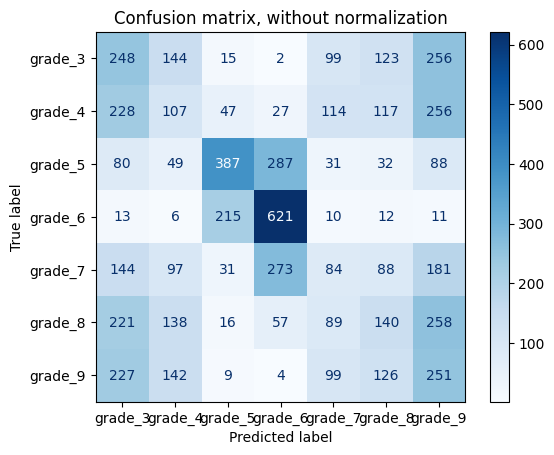

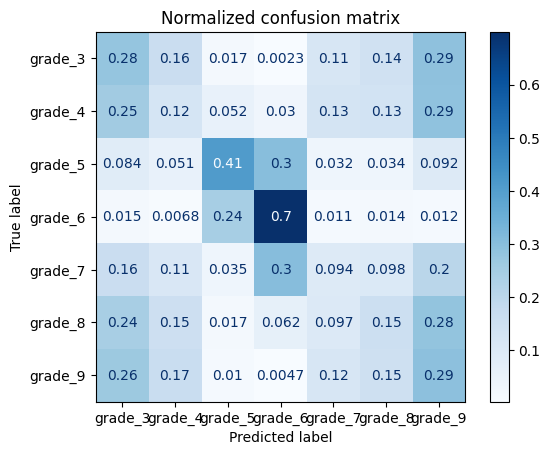

In [ ]:
logistic_regression_func(
    path_to_df="/content/drive/MyDrive/Colab Notebooks/csa806-big-data/data/wine_data.csv",
    target_column="quality",
    grid_search_params=parameters,
    affix="grade",

)

In [ ]:
# Check the training and loss crves
model = LogisticRegression(
    multi_class= "multinomial",
    solver= "sag", # "lbfgs", # Limited-memory Broyden-Fletcher-Goldfarb-Shanno generally good
    max_iter=200 #Maximum number of iterations taken for the solvers to converge.
)

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(max_iter=200, multi_class='multinomial', solver='sag')

In [ ]:
X_train

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
16485,-0.081645,-0.040537,0.821493,1.515159,2.303327,0.586502,1.485226,0.848392,0.766123,0.635225,-0.585124
19237,0.042638,0.452605,0.405719,0.678974,0.998597,0.184768,0.863351,1.032905,0.649414,0.218858,0.599139
15032,-1.324467,-1.684344,-1.231392,-1.571888,-1.322700,-1.042466,-0.429311,-1.610114,1.116249,-0.932272,0.937500
7781,-1.158757,-1.328186,-1.205406,-1.598183,-1.274673,-1.418282,-1.118065,-1.620087,0.299288,-1.275162,0.091598
18376,0.332629,-0.287108,1.575084,1.210136,0.102096,0.254747,0.105721,1.131810,2.224981,-0.858796,-1.177255
...,...,...,...,...,...,...,...,...,...,...,...
11284,-1.614458,-1.574757,-1.465265,-1.566629,-1.306691,-1.185017,-1.357632,-1.642528,1.174603,-1.299654,0.599139
11964,1.161178,-0.780250,0.899451,0.936666,0.190146,0.201614,1.544119,-0.439041,-1.217924,1.467957,0.260778
5390,0.332629,1.082732,0.639592,0.042632,1.150682,0.381747,1.068979,-0.551244,-0.225901,1.027099,-0.162173
860,-0.785910,0.480002,0.197832,-0.272909,0.118105,1.108757,0.991120,0.142756,1.057894,0.120890,0.852910


In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.29


In [ ]:
from yellowbrick.model_selection import LearningCurve

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 

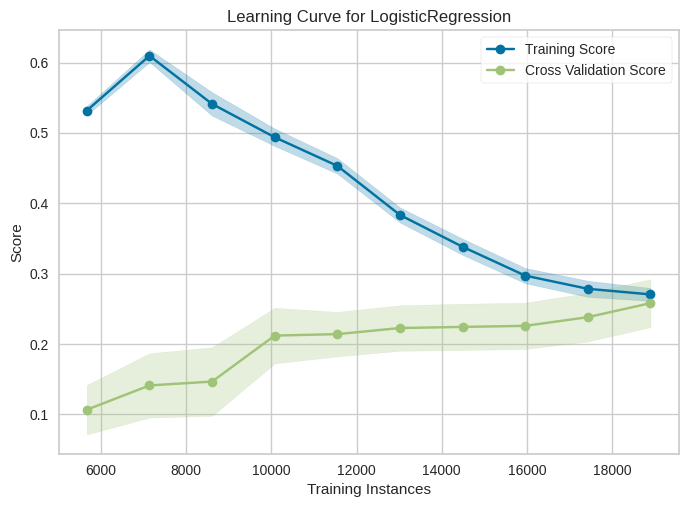

<Axes: title={'center': 'Learning Curve for LogisticRegression'}, xlabel='Training Instances', ylabel='Score'>

In [ ]:
sizes = np.linspace(0.3, 1.0, 10)
visualizer = LearningCurve(
    model, cv=10, scoring="f1_weighted", train_sizes=sizes, n_jobs=-1
)

visualizer.fit(X, y)
visualizer.show()

In [ ]:
LearningCurve?

In [ ]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0
...,...,...,...,...,...,...,...,...,...,...,...
20995,9.7,1.020,0.91,50.00,0.412,114.6,181.7,1.02085,3.30,0.89,12.0
20996,10.2,0.610,0.88,53.80,0.250,62.4,204.7,1.02776,3.52,1.14,9.7
20997,13.4,0.460,1.04,52.10,0.449,63.0,273.5,1.02618,2.89,1.76,9.3
20998,6.6,1.030,1.09,25.30,0.138,179.8,295.0,1.02476,2.94,1.54,12.9


In [ ]:
# def logistic_regression_func2(path_to_df, target_column, grid_search_params, affix=""):
#   """

#   """
#   # Import requisite packages
#   import plotly.express as px
#   import numpy as np
#   import matplotlib.pyplot as plt
#   from sklearn.preprocessing import MinMaxScaler, StandardScaler
#   from sklearn.model_selection import train_test_split
#   from sklearn.linear_model import LogisticRegression
#   from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
#   from sklearn.pipeline import Pipeline
#   # from sklearn.metrics import ConfusionMatrixDisplay

#   df = pd.read_csv(path_to_df)

#   # Only to be applied if the column is a numerical value
#   value = f"{affix}_"
#   def add_val(x):
#     return f"{value}{x}"

#   df[target_column] = df[target_column].apply(add_val)

#   # Features and target
#   X = df.drop(columns=target_column)
#   y = df[target_column]

#   # Features
#   features = X.columns

#   #
#   pipe = Pipeline(steps=[("scaler", StandardScaler()), ("LR", LogisticRegression())])

#   params = {
#       "LR__solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
#       "LR__max_iter": [20, 50, 100, 200, 500, 1000],
#       "LR__random_state": [42],
#       "LR__multi_class": ["multinomial"]
#   }
#   # # Standardize
#   # scaler = StandardScaler()
#   # X_standardized = X.copy()
#   # X_standardized[features] = scaler.fit_transform(X[features])
#   # X_standardized.head()

#   # Split the dataset into training and test sets
#   X_train, X_test, y_train, y_test = train_test_split(
#       X, y, test_size=0.3, random_state=42
#   )

#   # GridSearchCV
#   logistic_model_grid = GridSearchCV(
#       pipe,
#       param_grid=params, verbose=3,
#       cv=10, n_jobs=-1)

#   # Train the model
#   logistic_model_grid.fit(X_train, y_train)

#   # Best parameters
#   print("Best score for the model after tuning is: ",logistic_model_grid.best_score_)
#   print("Best parameters for the model is :",logistic_model_grid.best_estimator_)

#   # Make predictions
#   y_pred = logistic_model_grid.predict(X_test)

#   # Evaluate the model
#   accuracy = accuracy_score(y_test, y_pred)
#   print(f"Accuracy: {accuracy:.2f}")

#   # Classification report
#   report = classification_report(y_test, y_pred)
#   print(f"Classification report:\n {report}")


#   # Get class names
#   class_names = df[target_column].unique()
#   class_names

#   # Plot non-normalized confusion matrix
#   titles_options = [
#       ("Confusion matrix, without normalization", None),
#       ("Normalized confusion matrix", "true"),
#   ]
#   for title, normalize in titles_options:
#       disp = ConfusionMatrixDisplay.from_estimator(
#           model,
#           X_test,
#           y_test,
#           display_labels=class_names,
#           cmap=plt.cm.Blues,
#           normalize=normalize,
#       )
#       disp.ax_.set_title(title)

#       print(title)
#       print(disp.confusion_matrix)

#   plt.show()

In [ ]:
# logistic_regression_func2(
#     path_to_df="/content/drive/MyDrive/Colab Notebooks/csa806-big-data/data/wine_data.csv",
#     target_column="quality",
#     grid_search_params=parameters,
#     affix="grade",
# )